# Predicting default on credit card payments

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score


## Loading and preparing the data

In [2]:
df_taiwan= pd.read_csv('default+of+credit+card+clients_tiwan/default of credit card clients_with_information.csv')
df_taiwan.head()

,ID,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
0,1,20000,Female,University,Married,24,Delay 2 Months,Delay 2 Months,Paid Duly,Paid Duly,...,0,0,0,0,689,0,0,0,0,Yes
1,2,120000,Female,University,Single,26,Paid Duly,Delay 2 Months,No Consumption,No Consumption,...,3272,3455,3261,0,1000,1000,1000,0,2000,Yes
2,3,90000,Female,University,Single,34,No Consumption,No Consumption,No Consumption,No Consumption,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,No
3,4,50000,Female,University,Married,37,No Consumption,No Consumption,No Consumption,No Consumption,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,No
4,5,50000,Male,University,Married,57,Paid Duly,No Consumption,Paid Duly,No Consumption,...,20940,19146,19131,2000,36681,10000,9000,689,679,No


In [956]:
df_taiwan.shape

(30000, 25)

In [957]:
df_taiwan.isnull().sum()

ID                               0
Amount_of_Credit                 0
Gender                           0
Education_Level                345
Marital_Status                  54
Age                              0
Repayment_Status_Sep_2005     2759
Repayment_Status_Aug_2005     3782
Repayment_Status_Jul_2005     4085
Repayment_Status_Jun_2005     4348
Repayment_Status_May_2005     4546
Repayment_Status_Apr_2005     4895
Bill_Statement_Sep_2005          0
Bill_Statement_Aug_2005          0
Bill_Statement_Jul_2005          0
Bill_Statement_Jun_2005          0
Bill_Statement_May_2005          0
Bill_Statement_Apr_2005          0
Previous_Payment_Sep_2005        0
Previous_Payment_Aug_2005        0
Previous_Payment_Jul_2005        0
Previous_Payment_Jun_2005        0
Previous_Payment_May_2005        0
Previous_Payment_Apr_2005        0
Default_Payment_Next_Month       0
dtype: int64

Null values appeared after converting the dataframe because some variables were mapped based on a provided guide. However, the guide did not include definitions for certain variable values. As a result, when applying the mapping, any value not explicitly defined in the guide was converted to `NaN`.


In [3]:
df_taiwan = df_taiwan.dropna()

In [4]:
df_taiwan.isnull().sum()

ID                            0
Amount_of_Credit              0
Gender                        0
Education_Level               0
Marital_Status                0
Age                           0
Repayment_Status_Sep_2005     0
Repayment_Status_Aug_2005     0
Repayment_Status_Jul_2005     0
Repayment_Status_Jun_2005     0
Repayment_Status_May_2005     0
Repayment_Status_Apr_2005     0
Bill_Statement_Sep_2005       0
Bill_Statement_Aug_2005       0
Bill_Statement_Jul_2005       0
Bill_Statement_Jun_2005       0
Bill_Statement_May_2005       0
Bill_Statement_Apr_2005       0
Previous_Payment_Sep_2005     0
Previous_Payment_Aug_2005     0
Previous_Payment_Jul_2005     0
Previous_Payment_Jun_2005     0
Previous_Payment_May_2005     0
Previous_Payment_Apr_2005     0
Default_Payment_Next_Month    0
dtype: int64

In [5]:
df_taiwan.shape

(23150, 25)

In [961]:
#'our target is Default_Payment_Next_Month

## Feature Engineering

In [6]:
# Binary encoding of the target
df_taiwan['Default_Payment_Next_Month'] = df_taiwan['Default_Payment_Next_Month'].map({'Yes': 1, 'No': 0})

In [7]:
df_taiwan.dtypes

ID                             int64
Amount_of_Credit               int64
Gender                        object
Education_Level               object
Marital_Status                object
Age                            int64
Repayment_Status_Sep_2005     object
Repayment_Status_Aug_2005     object
Repayment_Status_Jul_2005     object
Repayment_Status_Jun_2005     object
Repayment_Status_May_2005     object
Repayment_Status_Apr_2005     object
Bill_Statement_Sep_2005        int64
Bill_Statement_Aug_2005        int64
Bill_Statement_Jul_2005        int64
Bill_Statement_Jun_2005        int64
Bill_Statement_May_2005        int64
Bill_Statement_Apr_2005        int64
Previous_Payment_Sep_2005      int64
Previous_Payment_Aug_2005      int64
Previous_Payment_Jul_2005      int64
Previous_Payment_Jun_2005      int64
Previous_Payment_May_2005      int64
Previous_Payment_Apr_2005      int64
Default_Payment_Next_Month     int64
dtype: object

In [8]:
df_taiwan['Education_Level'].unique()

array(['University', 'Graduate School', 'High School', 'Others'],
      dtype=object)

In [9]:
categorical_cols = [
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Repayment_Status_Sep_2005',
    'Repayment_Status_Aug_2005',
    'Repayment_Status_Jul_2005',
    'Repayment_Status_Jun_2005',
    'Repayment_Status_May_2005',
    'Repayment_Status_Apr_2005'
]


In [10]:
df_taiwan_FE=df_taiwan.copy()
df_taiwan_FE = df_taiwan_FE.drop(columns=['ID'])

In [11]:
df_taiwan['Repayment_Status_Jul_2005'].unique()

array(['No Consumption', 'Paid Duly', 'Delay 2 Months', 'Delay 3 Months',
       'Delay 4 Months', 'Delay 6 Months', 'Delay 7 Months',
       'Delay 1 Month', 'Delay 5 Months', 'Delay 8 Months'], dtype=object)

In [12]:
# Define the repayment status order
repayment_order = [
    'No Consumption', #0
    'Paid Duly',#1
    'Delay 1 Month',#2
    'Delay 2 Months',#3
    'Delay 3 Months',#4
    'Delay 4 Months',#5
    'Delay 5 Months',#6
    'Delay 6 Months',#7
    'Delay 7 Months',#8
    'Delay 8 Months'#9
]

# List of repayment status columns
repayment_cols = [
    'Repayment_Status_Sep_2005',
    'Repayment_Status_Aug_2005',
    'Repayment_Status_Jul_2005',
    'Repayment_Status_Jun_2005',
    'Repayment_Status_May_2005',
    'Repayment_Status_Apr_2005'
]

# Initialize encoder with the same category order for each column
encoder = OrdinalEncoder(
    categories=[repayment_order] * len(repayment_cols),
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Apply encoding
df_taiwan_FE[repayment_cols] = encoder.fit_transform(df_taiwan_FE[repayment_cols])

In [13]:
df_taiwan_FE

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
1,120000,Female,University,Single,26,1.0,3.0,0.0,0.0,0.0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,Female,University,Single,34,0.0,0.0,0.0,0.0,0.0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,Female,University,Married,37,0.0,0.0,0.0,0.0,0.0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,Male,University,Married,57,1.0,0.0,1.0,0.0,0.0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,50000,Male,Graduate School,Single,37,0.0,0.0,0.0,0.0,0.0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,Male,High School,Married,39,0.0,0.0,0.0,0.0,0.0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,Male,High School,Single,43,1.0,1.0,1.0,1.0,0.0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,Male,University,Single,37,5.0,4.0,3.0,1.0,0.0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,Male,High School,Married,41,2.0,1.0,0.0,0.0,0.0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [14]:
df_taiwan['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [15]:
gender_map = {'Male': 1, 'Female': 0}
df_taiwan_FE['Gender'] = df_taiwan_FE['Gender'].replace(gender_map).astype(int)

C:\Users\sabri\AppData\Local\Temp\ipykernel_17560\632629906.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_taiwan_FE['Gender'] = df_taiwan_FE['Gender'].replace(gender_map).astype(int)


In [16]:
df_taiwan['Education_Level'].unique()

array(['University', 'Graduate School', 'High School', 'Others'],
      dtype=object)

In [17]:
education_map = {
    'Others': 0,
    'High School': 1,
    'University': 2,
    'Graduate School': 3
}
df_taiwan_FE['Education_Level'] = df_taiwan_FE['Education_Level'].replace(education_map).astype(int)

C:\Users\sabri\AppData\Local\Temp\ipykernel_17560\2470650819.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_taiwan_FE['Education_Level'] = df_taiwan_FE['Education_Level'].replace(education_map).astype(int)


In [18]:
df_taiwan['Marital_Status'].unique()

array(['Single', 'Married', 'Others'], dtype=object)

In [19]:
marital_map = {
    'Others': 0,
    'Single': 1,
    'Married': 2
}
df_taiwan_FE['Marital_Status'] = df_taiwan_FE['Marital_Status'].replace(marital_map).astype(int)

C:\Users\sabri\AppData\Local\Temp\ipykernel_17560\1065652711.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_taiwan_FE['Marital_Status'] = df_taiwan_FE['Marital_Status'].replace(marital_map).astype(int)


In [20]:
df_taiwan_FE
df_taiwan_FE.to_csv('default+of+credit+card+clients_tiwan/df_taiwan_FE.csv')

In [21]:
df_taiwan_FE.shape

(23150, 24)

## Train Test Split

In [33]:
X, y = df_taiwan_FE.drop(columns=['Default_Payment_Next_Month']), df_taiwan_FE['Default_Payment_Next_Month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## KNN: first model

In [34]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train, y_train) # Training the model

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
pred = knn.predict(X_test) #predictions for new data points

In [36]:
knn.score(X_test, y_test)# evaluating the model using score to get the accuracy

0.7600431965442764

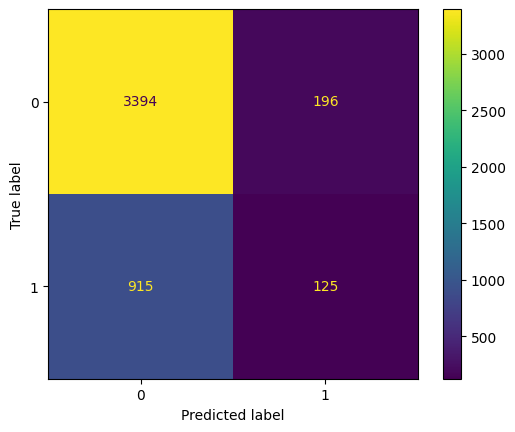

In [37]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test))

- True Negatives (3394): The model correctly identifies customers who will not default.
-  False Positives (196): The model incorrectly predicts default for customers who are actually solvent.
-  False Negatives (915): The model fails to detect a large number of customers who will default.
-  True Positives (125): The model correctly identifies some high-risk customers


In [38]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.79      0.95      0.86      3590
           1       0.39      0.12      0.18      1040

    accuracy                           0.76      4630
   macro avg       0.59      0.53      0.52      4630
weighted avg       0.70      0.76      0.71      4630



-  Class 0 is well predicted: High precision and recall indicate the model is very effective at identifying non-defaulters.
-  Class 1 is poorly predicted: Low recall (12%) means the model misses most actual defaulters, and the low F1-score (18%) confirms weak performance on this minority class.


In [39]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")

F1 Score     : 0.1837
Recall       : 0.1202
Precision    : 0.3894


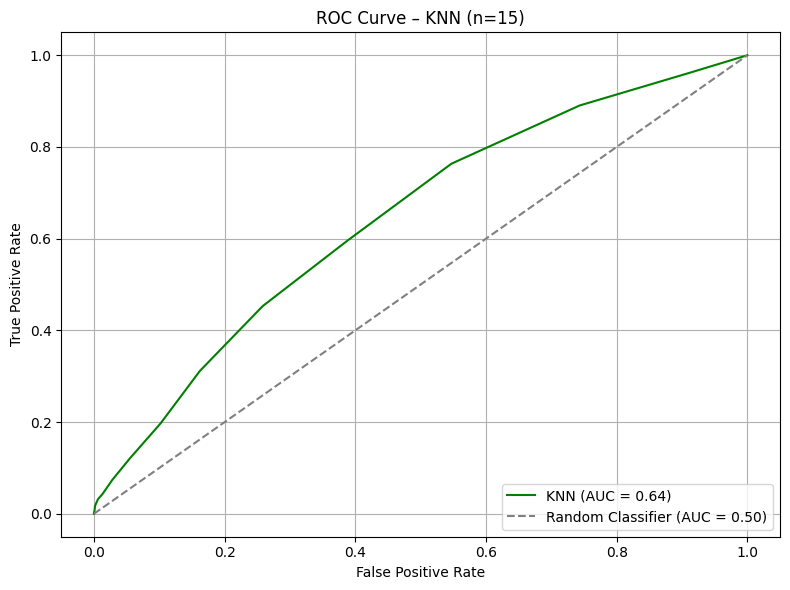

In [40]:
# Get predicted probabilities for the positive class (e.g., default = 1)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN (n=15)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
train = pd.DataFrame(X_train, columns = X_train.columns)
train["Default_Payment_Next_Month"] = y_train.values
default = train[train["Default_Payment_Next_Month"] == 1]
no_default = train[train["Default_Payment_Next_Month"] == 0]
train["Default_Payment_Next_Month"].value_counts()

Default_Payment_Next_Month
0    14198
1     4322
Name: count, dtype: int64

### Logistic Regression 

In [41]:
# Train model
logreg = LogisticRegression(max_iter=1000)
logreg
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_train)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test))

c:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ValueError: Found input variables with inconsistent numbers of samples: [4630, 18520]

## Normalization

In [987]:
# Create an instance of the normalizer
minmax = MinMaxScaler() 
#Fit it to our training data
minmax.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [988]:
#Transforming our training and testing data
X_train_transformed = minmax.transform(X_train)
X_test_transformed = minmax.transform(X_test)
# we do this because when applying transformations of our dataframe, normalizer will return an array instead of a dataframe object
X_train_transformed = pd.DataFrame(minmax.transform(X_train))
X_test_transformed = pd.DataFrame(minmax.transform(X_test))
X_train_transformed

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.080808,0.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.202272,0.164615,0.085757,0.264563,0.005941,0.001011,0.001362,0.001891,0.001172,0.001513
1,0.262626,0.0,0.666667,0.5,0.068966,0.000000,0.000000,0.000,0.000000,0.000,...,0.213874,0.184269,0.105868,0.280933,0.002733,0.001156,0.001588,0.001721,0.002209,0.001799
2,0.010101,0.0,0.666667,1.0,0.189655,0.444444,0.333333,0.000,0.000000,0.000,...,0.208100,0.170579,0.091474,0.269420,0.000000,0.000952,0.000429,0.000737,0.001482,0.001165
3,0.282828,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.311619,0.254520,0.164205,0.319657,0.007327,0.003264,0.004464,0.005672,0.006865,0.003783
4,0.020202,0.0,1.000000,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.212652,0.183295,0.105353,0.280406,0.002689,0.001382,0.001903,0.001961,0.002145,0.001757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18515,0.141414,0.0,0.666667,1.0,0.482759,0.111111,0.111111,0.000,0.111111,0.125,...,0.188958,0.161394,0.082747,0.261823,0.010137,0.000817,0.001491,0.004006,0.002574,0.001432
18516,0.151515,0.0,0.666667,0.5,0.086207,0.222222,0.333333,0.375,0.333333,0.125,...,0.185399,0.160138,0.081043,0.260979,0.000788,0.000000,0.000000,0.000753,0.000000,0.000000
18517,0.393939,1.0,0.666667,1.0,0.396552,0.111111,0.111111,0.000,0.000000,0.000,...,0.216229,0.174581,0.090559,0.264187,0.117960,0.000901,0.011184,0.000096,0.011101,0.003278
18518,0.010101,1.0,0.666667,0.5,0.120690,0.222222,0.333333,0.375,0.333333,0.000,...,0.205114,0.175769,0.098653,0.276006,0.000990,0.001630,0.000000,0.003781,0.003986,0.000000


In [989]:
X_train_transformed = pd.DataFrame(minmax.transform(X_train), columns=X_train.columns)
X_test_transformed = pd.DataFrame(minmax.transform(X_test), columns=X_train.columns)
X_test_transformed

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jul_2005,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005
0,0.020202,0.0,0.666667,0.5,0.224138,0.333333,0.111111,0.375,0.333333,0.375,...,0.222372,0.195062,0.117992,0.289339,0.065347,0.026893,0.006484,0.002505,0.000000,0.005854
1,0.313131,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.451574,0.369521,0.302947,0.435298,0.019935,0.008964,0.005580,0.008544,0.006204,0.040587
2,0.090909,0.0,1.000000,1.0,0.310345,0.000000,0.000000,0.000,0.333333,0.375,...,0.193512,0.166762,0.088494,0.266851,0.002178,0.002852,0.000000,0.001891,0.000000,0.009458
3,0.303030,0.0,1.000000,0.5,0.068966,0.333333,0.000000,0.000,0.000000,0.000,...,0.462209,0.337260,0.250105,0.313519,0.023123,0.006850,0.006696,0.009594,0.007034,0.005675
4,0.191919,0.0,1.000000,0.5,0.120690,0.000000,0.000000,0.000,0.000000,0.000,...,0.355360,0.286863,0.208952,0.356702,0.063366,0.048896,0.007037,0.008130,0.010550,0.008512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4625,0.050505,1.0,0.333333,0.5,0.224138,0.111111,0.111111,0.125,0.111111,0.125,...,0.185314,0.160445,0.081120,0.261229,0.000646,0.000266,0.000364,0.000900,0.000764,0.000617
4626,0.090909,1.0,0.333333,0.5,0.086207,0.000000,0.000000,0.000,0.000000,0.000,...,0.223794,0.191329,0.080648,0.261528,0.004606,0.001630,0.001451,0.000000,0.001676,0.000000
4627,0.252525,1.0,1.000000,0.5,0.137931,0.000000,0.000000,0.000,0.000000,0.000,...,0.246176,0.204131,0.127748,0.295583,0.011881,0.004890,0.005580,0.009454,0.009378,0.009458
4628,0.040404,1.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.208616,0.178902,0.100204,0.276684,0.002630,0.001072,0.000785,0.001367,0.002462,0.001264


In [990]:
train = pd.DataFrame(X_train_transformed, columns = X_train.columns)
train["Default_Payment_Next_Month"] = y_train.values
default = train[train["Default_Payment_Next_Month"] == 1]
no_default = train[train["Default_Payment_Next_Month"] == 0]
train["Default_Payment_Next_Month"].value_counts()

Default_Payment_Next_Month
0    14198
1     4322
Name: count, dtype: int64

In [991]:
X_train_transformed

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jul_2005,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005
0,0.080808,0.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.202272,0.164615,0.085757,0.264563,0.005941,0.001011,0.001362,0.001891,0.001172,0.001513
1,0.262626,0.0,0.666667,0.5,0.068966,0.000000,0.000000,0.000,0.000000,0.000,...,0.213874,0.184269,0.105868,0.280933,0.002733,0.001156,0.001588,0.001721,0.002209,0.001799
2,0.010101,0.0,0.666667,1.0,0.189655,0.444444,0.333333,0.000,0.000000,0.000,...,0.208100,0.170579,0.091474,0.269420,0.000000,0.000952,0.000429,0.000737,0.001482,0.001165
3,0.282828,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.311619,0.254520,0.164205,0.319657,0.007327,0.003264,0.004464,0.005672,0.006865,0.003783
4,0.020202,0.0,1.000000,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.212652,0.183295,0.105353,0.280406,0.002689,0.001382,0.001903,0.001961,0.002145,0.001757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18515,0.141414,0.0,0.666667,1.0,0.482759,0.111111,0.111111,0.000,0.111111,0.125,...,0.188958,0.161394,0.082747,0.261823,0.010137,0.000817,0.001491,0.004006,0.002574,0.001432
18516,0.151515,0.0,0.666667,0.5,0.086207,0.222222,0.333333,0.375,0.333333,0.125,...,0.185399,0.160138,0.081043,0.260979,0.000788,0.000000,0.000000,0.000753,0.000000,0.000000
18517,0.393939,1.0,0.666667,1.0,0.396552,0.111111,0.111111,0.000,0.000000,0.000,...,0.216229,0.174581,0.090559,0.264187,0.117960,0.000901,0.011184,0.000096,0.011101,0.003278
18518,0.010101,1.0,0.666667,0.5,0.120690,0.222222,0.333333,0.375,0.333333,0.000,...,0.205114,0.175769,0.098653,0.276006,0.000990,0.001630,0.000000,0.003781,0.003986,0.000000


### KNN

In [992]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_transformed, y_train) # Training the model

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [993]:
pred = knn.predict(X_test_transformed) #predictions for new data points

In [994]:
knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.8125269978401728

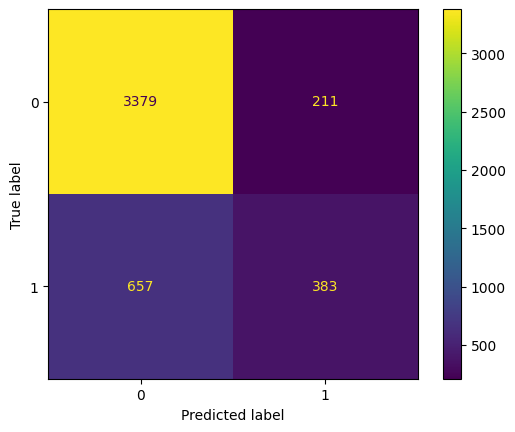

In [995]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

-  True Negatives (3379): Correctly predicted non-defaulters.
-  False Positives (211): Non-defaulters incorrectly flagged as defaulters.
-  False Negatives (657): Defaulters missed by the model.
-  True Positives (383): Correctly identified defaulters


In [996]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3590
           1       0.64      0.37      0.47      1040

    accuracy                           0.81      4630
   macro avg       0.74      0.65      0.68      4630
weighted avg       0.79      0.81      0.79      4630



-  Class 0 remains strong: High precision and recall confirm reliable identification of non-defaulters.
-  Class 1 shows significant improvement:
- Precision increased from 0.39 → 0.64
- Recall increased from 0.12 → 0.37
- F1-score increased from 0.18 → 0.47
This means the model is now better at identifying actual defaulters, with fewer false negatives.


In [997]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)
y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {roc_auc_knn:.4f}")


F1 Score     : 0.4688
Recall       : 0.3683
Precision    : 0.6448
AUC          : 0.7534


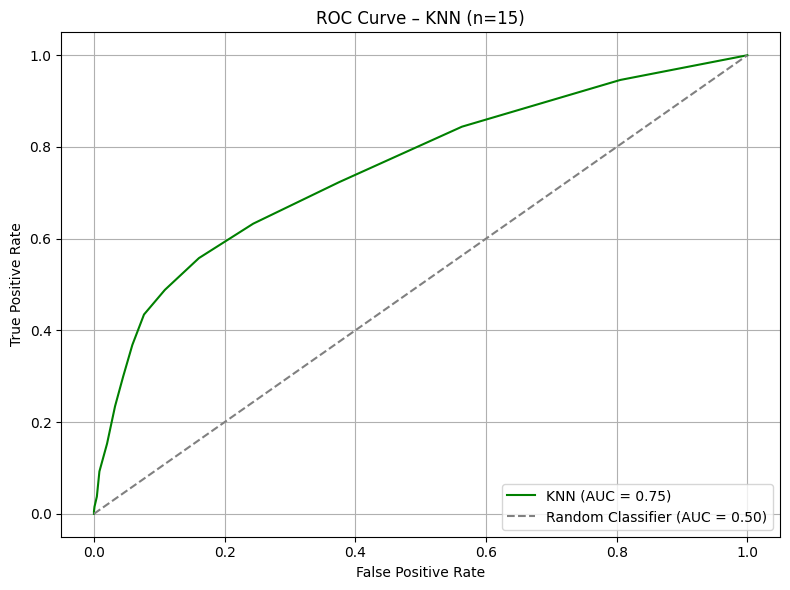

In [998]:
# Get predicted probabilities for the positive class (e.g., default = 1)
y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]

# Compute ROC curve and AUC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN (n=15)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Logistic Regression

In [999]:
# Train model
logreg = LogisticRegression(max_iter=1000)
logreg

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3590
           1       0.66      0.39      0.49      1040

    accuracy                           0.82      4630
   macro avg       0.75      0.66      0.69      4630
weighted avg       0.80      0.82      0.80      4630



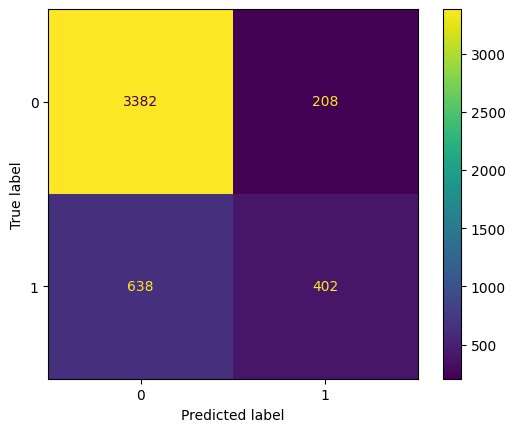

In [1000]:
logreg.fit(X_train_transformed, y_train)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [1001]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
roc_auc_logreg  = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {roc_auc_logreg :.4f}")


F1 Score     : 0.4873
Recall       : 0.3865
Precision    : 0.6590
AUC          : 0.7738


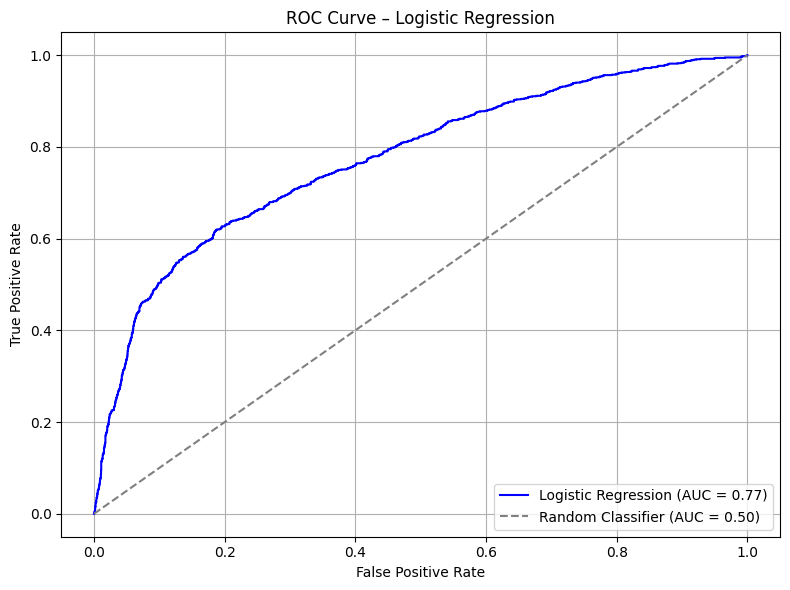

In [1002]:
# Get predicted probabilities for the positive class (e.g., default = 1)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]

# Compute ROC curve and AUC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forest

In [1003]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3590
           1       0.66      0.40      0.50      1040

    accuracy                           0.82      4630
   macro avg       0.75      0.67      0.69      4630
weighted avg       0.80      0.82      0.80      4630



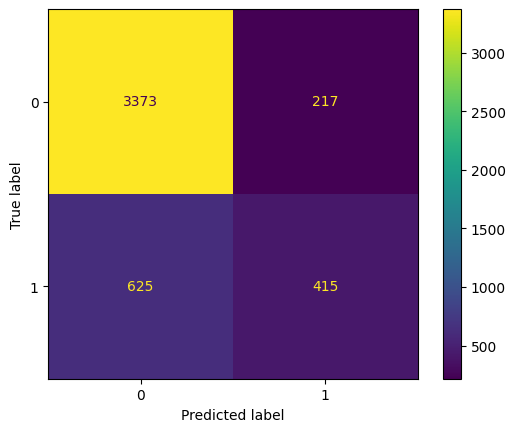

In [1004]:
rf_model.fit(X_train_transformed, y_train)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [1005]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {roc_auc_rf:.4f}")

F1 Score     : 0.4964
Recall       : 0.3990
Precision    : 0.6566
AUC          : 0.7714


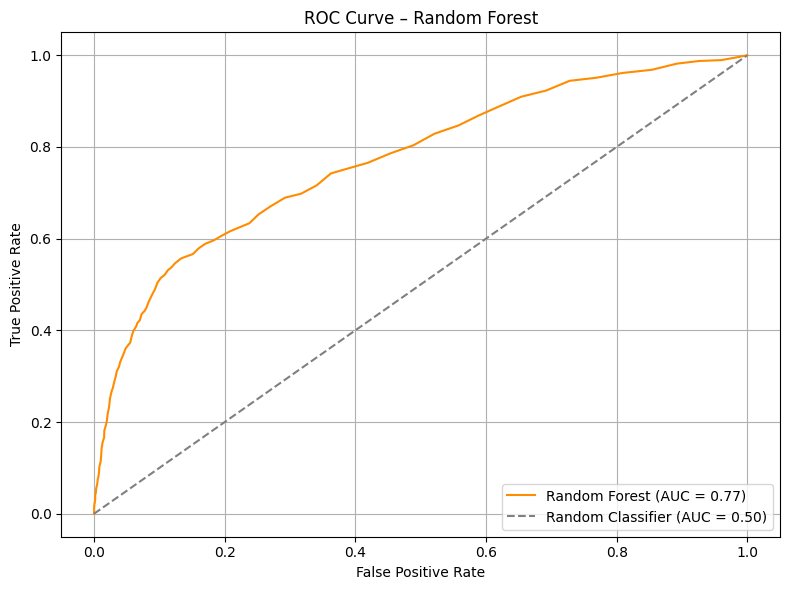

In [1006]:
# Get predicted probabilities for the positive class (e.g., default = 1)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

# Compute ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Gradient Boosting

In [1007]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


              precision    recall  f1-score   support

           0       0.85      0.94      0.89      3590
           1       0.66      0.42      0.51      1040

    accuracy                           0.82      4630
   macro avg       0.76      0.68      0.70      4630
weighted avg       0.81      0.82      0.81      4630



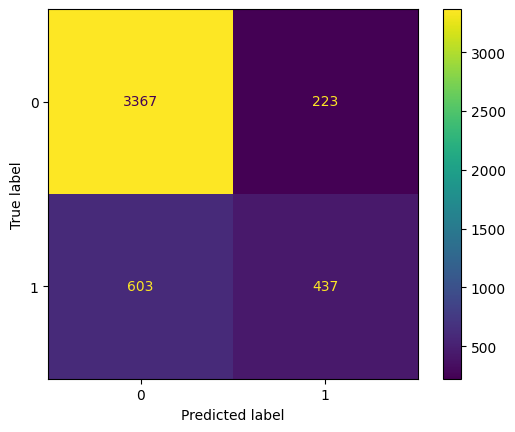

In [1008]:
gb_model.fit(X_train_transformed, y_train)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [1009]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = gb_model.predict_proba(X_test_transformed)[:, 1]
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {roc_auc_gb:.4f}")

F1 Score     : 0.5141
Recall       : 0.4202
Precision    : 0.6621
AUC          : 0.7848


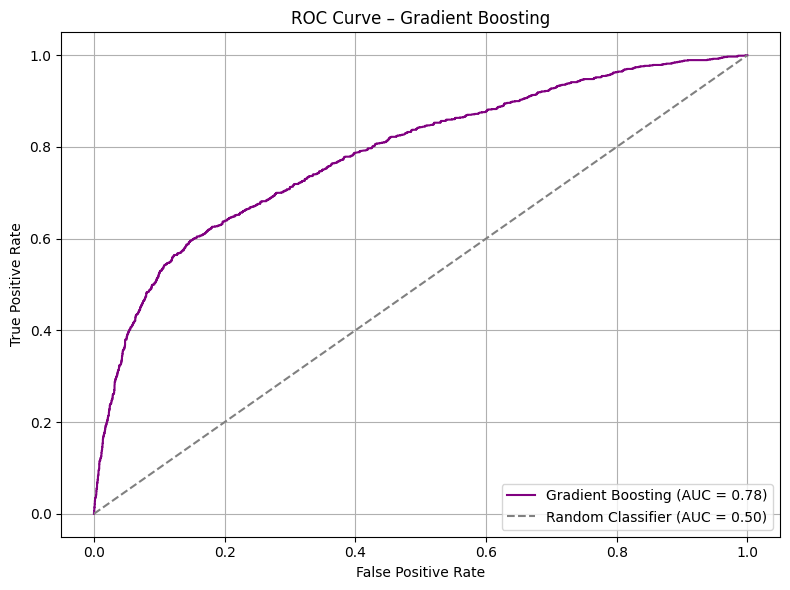

In [1010]:
# Get predicted probabilities for the positive class (e.g., default = 1)
y_proba_gb = gb_model.predict_proba(X_test_transformed)[:, 1]

# Compute ROC curve and AUC
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1011]:
# Define model performance metrics
model_metrics = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.4688, 0.4873, 0.4964, 0.5141],
    "Recall": [0.3683, 0.3865, 0.3990, 0.4202],
    "Precision": [0.6448, 0.6590, 0.6566, 0.6621]
}

# Create DataFrame
df_metrics = pd.DataFrame(model_metrics)

# Display the table
df_metrics

,Model,F1 Score,Recall,Precision
0,K-Nearest Neighbors,0.4688,0.3683,0.6448
1,Logistic Regression,0.4873,0.3865,0.6590
2,Random Forest,0.4964,0.3990,0.6566
3,Gradient Boosting,0.5141,0.4202,0.6621


### performance results after normalization

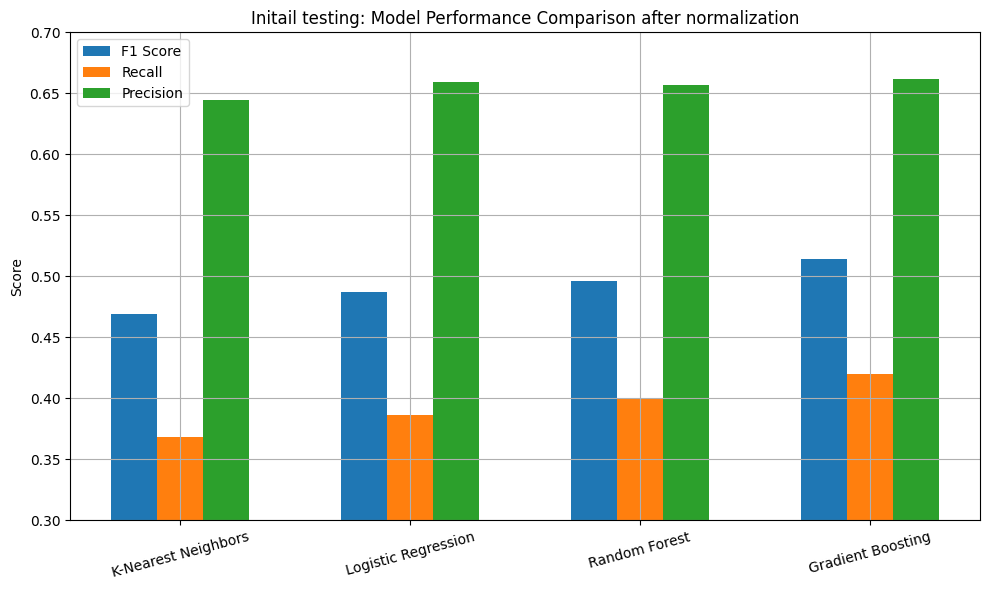

In [1012]:
# Set figure size
plt.figure(figsize=(10, 6))

# Plot each metric as a separate bar chart
bar_width = 0.2
x = range(len(df_metrics["Model"]))

plt.bar([i - bar_width for i in x], df_metrics["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_metrics["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_metrics["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_metrics["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Initail testing: Model Performance Comparison after normalization")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

## Imbalanced

### Oversampling

In [1013]:
train = pd.DataFrame(X_train_transformed, columns = X_train.columns)
train["Default_Payment_Next_Month"] = y_train.values

default = train[train["Default_Payment_Next_Month"] == 1]
no_default = train[train["Default_Payment_Next_Month"] == 0]

In [1014]:
print(train["Default_Payment_Next_Month"].value_counts())

Default_Payment_Next_Month
0    14198
1     4322
Name: count, dtype: int64


In [1015]:
# Oversample the minority class
default_oversampled = resample(
    default,
    replace=True,                # Sample with replacement
    n_samples=len(no_default),   # Match majority class size
    random_state=42              # For reproducibility
)

# Combine with majority class
train_over = pd.concat([no_default, default_oversampled])
train_over

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
0,0.080808,0.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.164615,0.085757,0.264563,0.005941,0.001011,0.001362,0.001891,0.001172,0.001513,0
1,0.262626,0.0,0.666667,0.5,0.068966,0.000000,0.000000,0.000,0.000000,0.000,...,0.184269,0.105868,0.280933,0.002733,0.001156,0.001588,0.001721,0.002209,0.001799,0
3,0.282828,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.254520,0.164205,0.319657,0.007327,0.003264,0.004464,0.005672,0.006865,0.003783,0
4,0.020202,0.0,1.000000,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.183295,0.105353,0.280406,0.002689,0.001382,0.001903,0.001961,0.002145,0.001757,0
6,0.070707,0.0,0.333333,1.0,0.258621,0.000000,0.000000,0.000,0.000000,0.000,...,0.231163,0.133571,0.303671,0.039604,0.004075,0.003348,0.009454,0.007034,0.005675,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14415,0.191919,0.0,1.000000,0.5,0.396552,0.000000,0.000000,0.000,0.000000,0.000,...,0.290567,0.214011,0.358282,0.008913,0.004006,0.005028,0.007951,0.009718,0.005864,1
1101,0.090909,0.0,1.000000,0.5,0.103448,0.000000,0.000000,0.000,0.000000,0.000,...,0.201604,0.124860,0.295961,0.003915,0.001467,0.002268,0.003025,0.003873,0.003280,1
8607,0.090909,1.0,1.000000,1.0,0.172414,0.000000,0.000000,0.000,0.000000,0.000,...,0.191713,0.109334,0.284401,0.002988,0.001301,0.001696,0.002836,0.004689,0.050533,1
259,0.121212,0.0,1.000000,1.0,0.275862,0.333333,0.333333,0.375,0.333333,0.375,...,0.202871,0.126352,0.297240,0.006139,0.001222,0.002232,0.003025,0.004689,0.003783,1


In [1016]:
print(train_over["Default_Payment_Next_Month"].value_counts())

Default_Payment_Next_Month
0    14198
1    14198
Name: count, dtype: int64


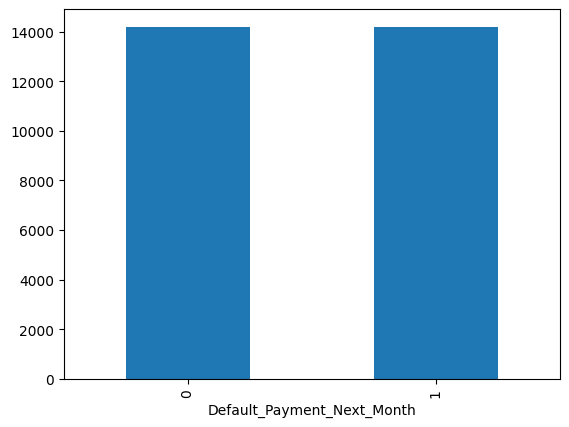

In [1017]:
y_plt = train_over["Default_Payment_Next_Month"].value_counts()
y_plt.plot(kind="bar")
plt.show()

In [1018]:
X_train_over = train_over.drop("Default_Payment_Next_Month", axis=1)
y_train_over = train_over["Default_Payment_Next_Month"]

#### KNN

In [1019]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_over, y_train_over) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.7077753779697624

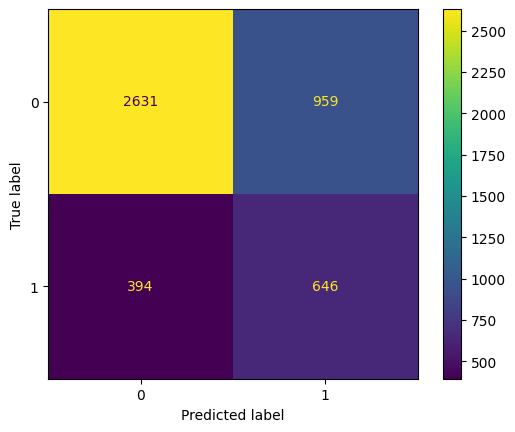

In [1020]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

In [1021]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.87      0.73      0.80      3590
           1       0.40      0.62      0.49      1040

    accuracy                           0.71      4630
   macro avg       0.64      0.68      0.64      4630
weighted avg       0.76      0.71      0.73      4630



In [1022]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.4885
Recall       : 0.6212
Precision    : 0.4025
AUC          : 0.7376


#### Logistic regression

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      3590
           1       0.51      0.59      0.55      1040

    accuracy                           0.78      4630
   macro avg       0.69      0.71      0.70      4630
weighted avg       0.79      0.78      0.79      4630



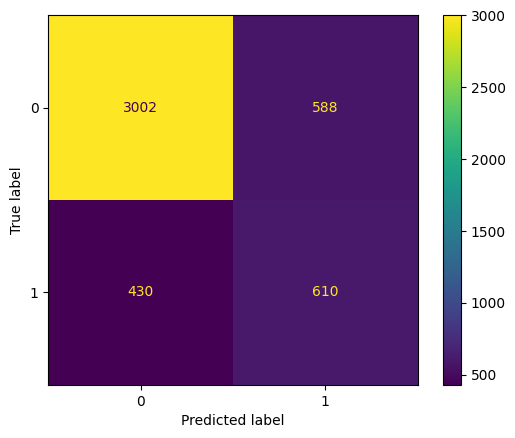

In [1023]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_over, y_train_over)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [1024]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5451
Recall       : 0.5865
Precision    : 0.5092
AUC          : 0.7762


#### Random Forest

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      3590
           1       0.62      0.46      0.53      1040

    accuracy                           0.82      4630
   macro avg       0.74      0.69      0.71      4630
weighted avg       0.80      0.82      0.81      4630



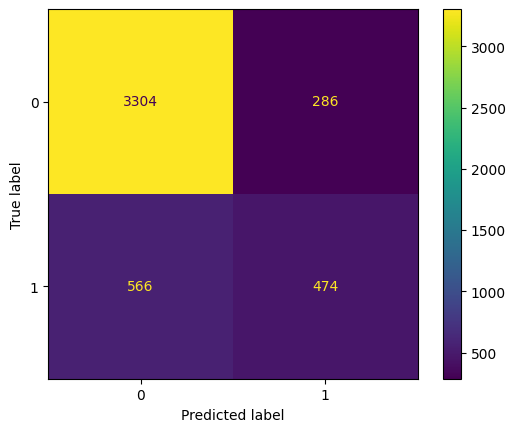

In [1025]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_over, y_train_over)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [1026]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5267
Recall       : 0.4558
Precision    : 0.6237
AUC          : 0.7775


#### Gradient Boosting

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      3590
           1       0.52      0.62      0.56      1040

    accuracy                           0.78      4630
   macro avg       0.70      0.73      0.71      4630
weighted avg       0.80      0.78      0.79      4630



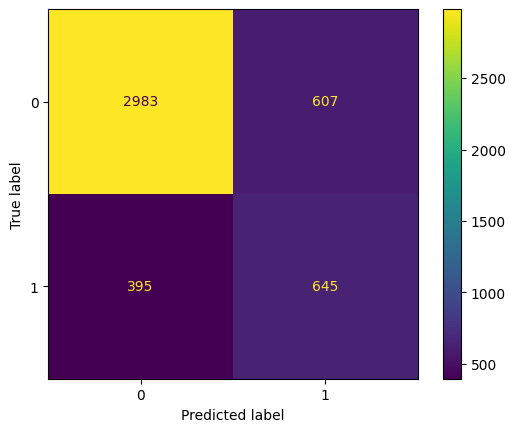

In [1027]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_over, y_train_over)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [1028]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = gb_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5628
Recall       : 0.6202
Precision    : 0.5152
AUC          : 0.7873


#### Oversampling results

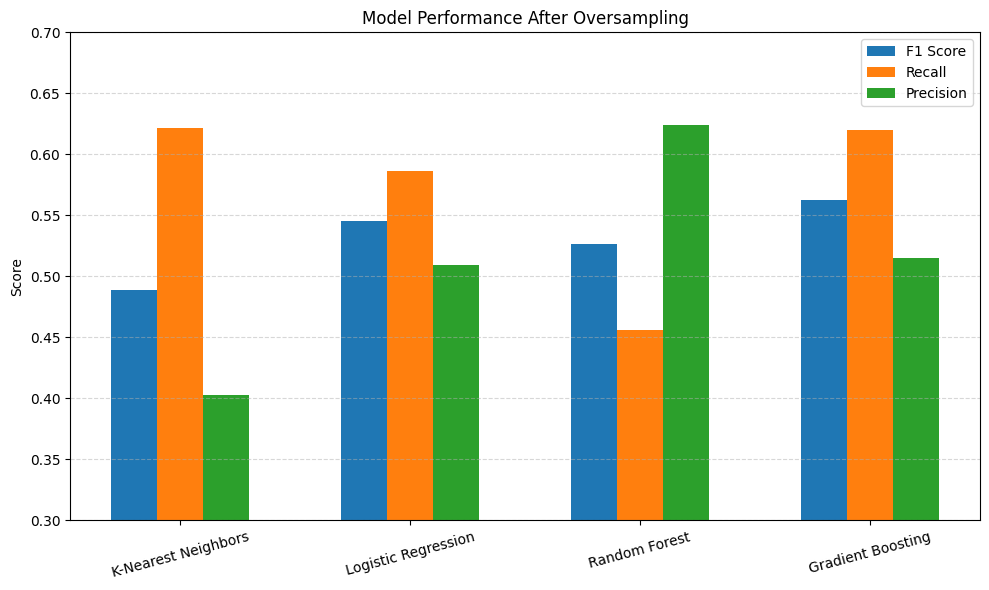

In [1029]:
# Define model performance metrics (post-oversampling)
model_metrics = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.4885, 0.5451, 0.5267, 0.5628],
    "Recall": [0.6212, 0.5865, 0.4558, 0.6202],
    "Precision": [0.4025, 0.5092, 0.6237, 0.5152]
}

# Create DataFrame
df_metrics = pd.DataFrame(model_metrics)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_metrics["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_metrics["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_metrics["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_metrics["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_metrics["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After Oversampling")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

### Undersampling

In [1030]:
train

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
0,0.080808,0.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.164615,0.085757,0.264563,0.005941,0.001011,0.001362,0.001891,0.001172,0.001513,0
1,0.262626,0.0,0.666667,0.5,0.068966,0.000000,0.000000,0.000,0.000000,0.000,...,0.184269,0.105868,0.280933,0.002733,0.001156,0.001588,0.001721,0.002209,0.001799,0
2,0.010101,0.0,0.666667,1.0,0.189655,0.444444,0.333333,0.000,0.000000,0.000,...,0.170579,0.091474,0.269420,0.000000,0.000952,0.000429,0.000737,0.001482,0.001165,1
3,0.282828,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.254520,0.164205,0.319657,0.007327,0.003264,0.004464,0.005672,0.006865,0.003783,0
4,0.020202,0.0,1.000000,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.183295,0.105353,0.280406,0.002689,0.001382,0.001903,0.001961,0.002145,0.001757,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18515,0.141414,0.0,0.666667,1.0,0.482759,0.111111,0.111111,0.000,0.111111,0.125,...,0.161394,0.082747,0.261823,0.010137,0.000817,0.001491,0.004006,0.002574,0.001432,0
18516,0.151515,0.0,0.666667,0.5,0.086207,0.222222,0.333333,0.375,0.333333,0.125,...,0.160138,0.081043,0.260979,0.000788,0.000000,0.000000,0.000753,0.000000,0.000000,0
18517,0.393939,1.0,0.666667,1.0,0.396552,0.111111,0.111111,0.000,0.000000,0.000,...,0.174581,0.090559,0.264187,0.117960,0.000901,0.011184,0.000096,0.011101,0.003278,0
18518,0.010101,1.0,0.666667,0.5,0.120690,0.222222,0.333333,0.375,0.333333,0.000,...,0.175769,0.098653,0.276006,0.000990,0.001630,0.000000,0.003781,0.003986,0.000000,0


In [1031]:
# Undersample the majority class
no_default_undersampled = resample(
    no_default,
    replace=False,                 # No replacement
    n_samples=len(default),        # Match minority class size
    random_state=42                # For reproducibility
)

# Combine with minority class
train_under = pd.concat([default, no_default_undersampled])

In [1032]:
print(train_under["Default_Payment_Next_Month"].value_counts())

Default_Payment_Next_Month
1    4322
0    4322
Name: count, dtype: int64


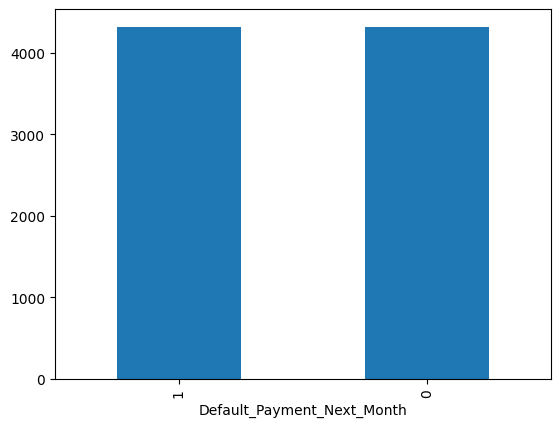

In [1033]:
y_plt = train_under["Default_Payment_Next_Month"].value_counts()
y_plt.plot(kind="bar")
plt.show()

In [1034]:
X_train_under = train_under.drop("Default_Payment_Next_Month", axis=1)
y_train_under = train_under["Default_Payment_Next_Month"]

#### KNN

In [1035]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_under, y_train_under) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.7416846652267819

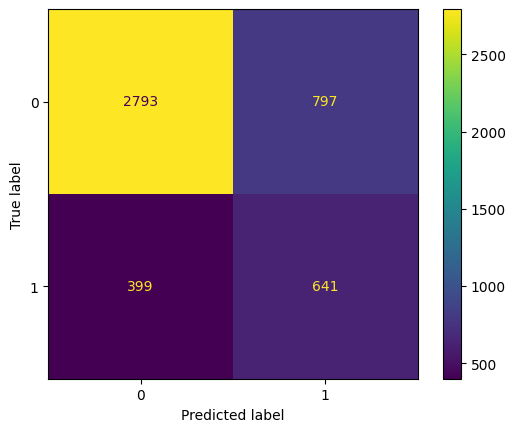

In [1036]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

In [1037]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82      3590
           1       0.45      0.62      0.52      1040

    accuracy                           0.74      4630
   macro avg       0.66      0.70      0.67      4630
weighted avg       0.78      0.74      0.75      4630



In [1038]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5174
Recall       : 0.6163
Precision    : 0.4458
AUC          : 0.7607


#### Logistic regression

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      3590
           1       0.51      0.59      0.55      1040

    accuracy                           0.78      4630
   macro avg       0.69      0.71      0.70      4630
weighted avg       0.79      0.78      0.79      4630



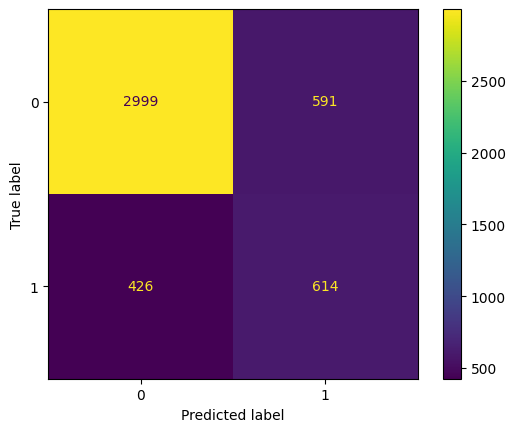

In [1039]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_under, y_train_under)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [1040]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5470
Recall       : 0.5904
Precision    : 0.5095
AUC          : 0.7754


#### Random Forest

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      3590
           1       0.46      0.64      0.53      1040

    accuracy                           0.75      4630
   macro avg       0.67      0.71      0.68      4630
weighted avg       0.79      0.75      0.76      4630



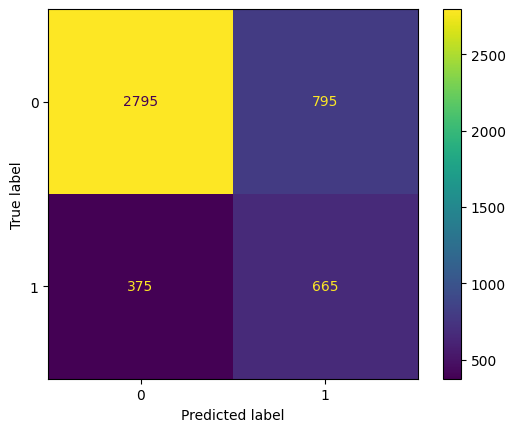

In [1041]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_under, y_train_under)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [1042]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5320
Recall       : 0.6394
Precision    : 0.4555
AUC          : 0.7793


#### Gradient Boosting

              precision    recall  f1-score   support

           0       0.88      0.81      0.85      3590
           1       0.49      0.64      0.55      1040

    accuracy                           0.77      4630
   macro avg       0.69      0.72      0.70      4630
weighted avg       0.80      0.77      0.78      4630



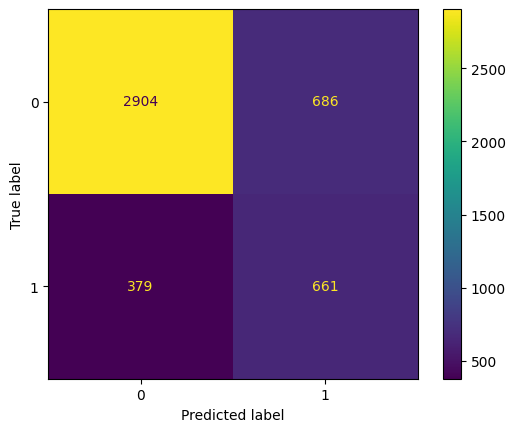

In [1043]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_under, y_train_under)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [1044]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = gb_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5538
Recall       : 0.6356
Precision    : 0.4907
AUC          : 0.7865


#### undersampling results

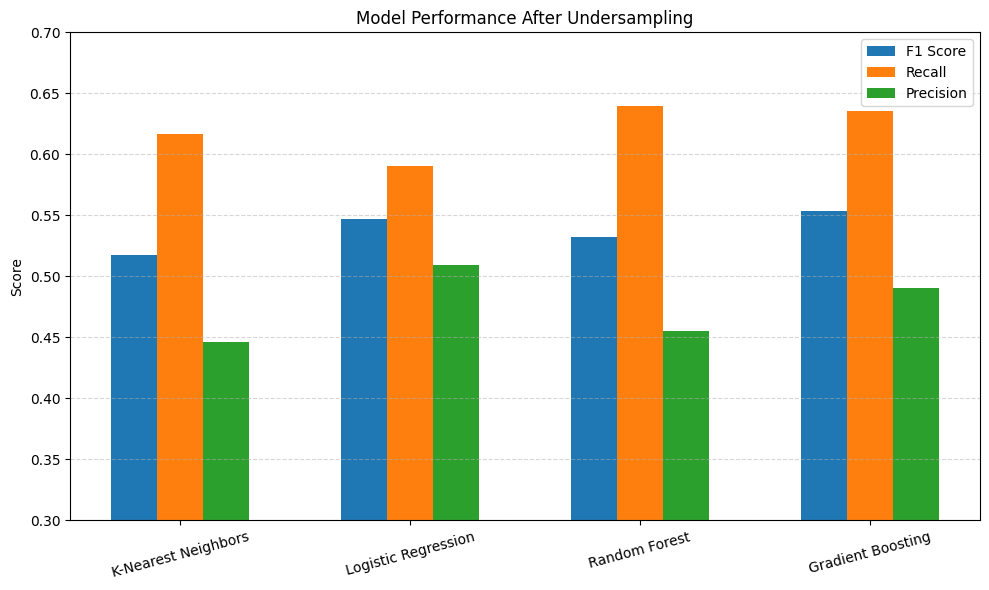

In [1045]:
# Define model performance metrics (post-undersampling)
model_metrics_under = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.5174, 0.5470, 0.5320, 0.5538],
    "Recall": [0.6163, 0.5904, 0.6394, 0.6356],
    "Precision": [0.4458, 0.5095, 0.4555, 0.4907]
}

# Create DataFrame
df_under = pd.DataFrame(model_metrics_under)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_under["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_under["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_under["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_under["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_under["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After Undersampling")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

### SMOTE

In [1046]:
train

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
0,0.080808,0.0,0.666667,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.164615,0.085757,0.264563,0.005941,0.001011,0.001362,0.001891,0.001172,0.001513,0
1,0.262626,0.0,0.666667,0.5,0.068966,0.000000,0.000000,0.000,0.000000,0.000,...,0.184269,0.105868,0.280933,0.002733,0.001156,0.001588,0.001721,0.002209,0.001799,0
2,0.010101,0.0,0.666667,1.0,0.189655,0.444444,0.333333,0.000,0.000000,0.000,...,0.170579,0.091474,0.269420,0.000000,0.000952,0.000429,0.000737,0.001482,0.001165,1
3,0.282828,0.0,0.666667,1.0,0.206897,0.000000,0.000000,0.000,0.000000,0.000,...,0.254520,0.164205,0.319657,0.007327,0.003264,0.004464,0.005672,0.006865,0.003783,0
4,0.020202,0.0,1.000000,0.5,0.051724,0.000000,0.000000,0.000,0.000000,0.000,...,0.183295,0.105353,0.280406,0.002689,0.001382,0.001903,0.001961,0.002145,0.001757,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18515,0.141414,0.0,0.666667,1.0,0.482759,0.111111,0.111111,0.000,0.111111,0.125,...,0.161394,0.082747,0.261823,0.010137,0.000817,0.001491,0.004006,0.002574,0.001432,0
18516,0.151515,0.0,0.666667,0.5,0.086207,0.222222,0.333333,0.375,0.333333,0.125,...,0.160138,0.081043,0.260979,0.000788,0.000000,0.000000,0.000753,0.000000,0.000000,0
18517,0.393939,1.0,0.666667,1.0,0.396552,0.111111,0.111111,0.000,0.000000,0.000,...,0.174581,0.090559,0.264187,0.117960,0.000901,0.011184,0.000096,0.011101,0.003278,0
18518,0.010101,1.0,0.666667,0.5,0.120690,0.222222,0.333333,0.375,0.333333,0.000,...,0.175769,0.098653,0.276006,0.000990,0.001630,0.000000,0.003781,0.003986,0.000000,0


In [1047]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1048]:
"""- **sampling_strategy** - corresponds to the ratio of the number of samples in the minority class over the number of samples in the majority class."""
smote = SMOTE(random_state = 42,sampling_strategy=1.0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

#### KNN

In [1049]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_resampled, y_train_resampled) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.6928725701943844

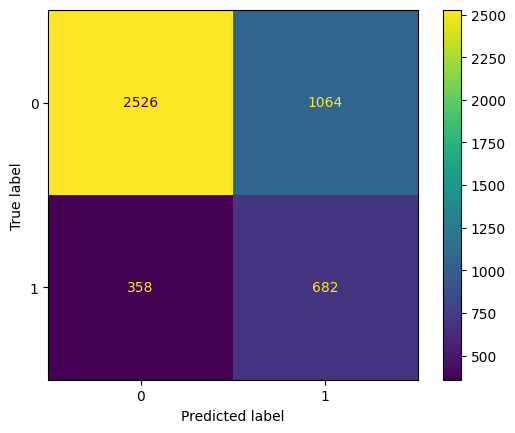

In [1050]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

In [1051]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      3590
           1       0.39      0.66      0.49      1040

    accuracy                           0.69      4630
   macro avg       0.63      0.68      0.63      4630
weighted avg       0.77      0.69      0.72      4630



In [1052]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.4896
Recall       : 0.6558
Precision    : 0.3906
AUC          : 0.7422


#### Logistic regression

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      3590
           1       0.51      0.59      0.55      1040

    accuracy                           0.78      4630
   macro avg       0.69      0.71      0.70      4630
weighted avg       0.79      0.78      0.79      4630



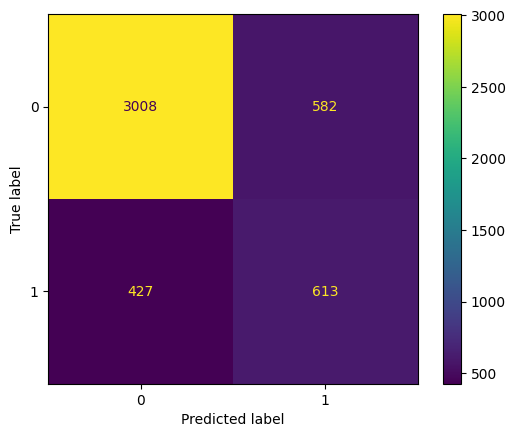

In [1053]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [1054]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5485
Recall       : 0.5894
Precision    : 0.5130
AUC          : 0.7746


#### Random Forest

              precision    recall  f1-score   support

           0       0.86      0.89      0.88      3590
           1       0.57      0.51      0.54      1040

    accuracy                           0.80      4630
   macro avg       0.72      0.70      0.71      4630
weighted avg       0.80      0.80      0.80      4630



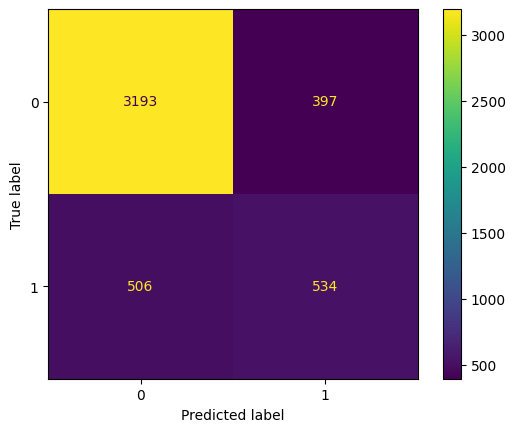

In [1055]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [1056]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5419
Recall       : 0.5135
Precision    : 0.5736
AUC          : 0.7737


#### Gradient Boosting

              precision    recall  f1-score   support

           0       0.87      0.88      0.87      3590
           1       0.56      0.54      0.55      1040

    accuracy                           0.80      4630
   macro avg       0.72      0.71      0.71      4630
weighted avg       0.80      0.80      0.80      4630



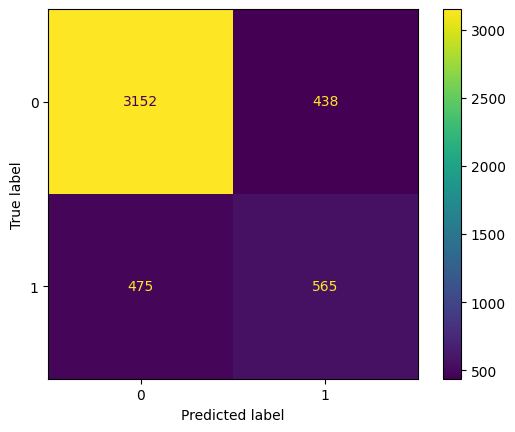

In [1089]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [1058]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = gb_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.5531
Recall       : 0.5433
Precision    : 0.5633
AUC          : 0.7740


#### SMOTE results

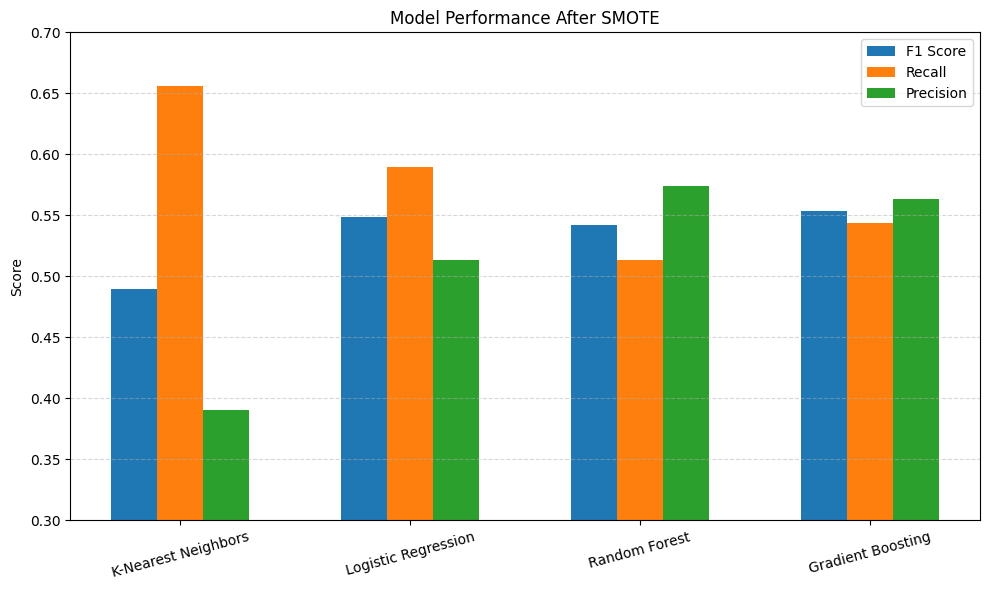

In [1059]:
# Define model performance metrics (post-SMOTE)
model_metrics_smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.4896, 0.5485, 0.5419, 0.5531],
    "Recall": [0.6558, 0.5894, 0.5135, 0.5433],
    "Precision": [0.3906, 0.5130, 0.5736, 0.5633]
}

# Create DataFrame
df_smote = pd.DataFrame(model_metrics_smote)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_smote["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_smote["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_smote["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_smote["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_smote["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After SMOTE")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

In [1060]:
# Define performance metrics
models = ["KNN", "Logistic Regression", "Random Forest", "Gradient Boosting"]
methods = ["Normalization", "Oversampling", "Undersampling", "SMOTE"]

f1_scores = {
    "Oversampling": [0.4885, 0.5451, 0.5267, 0.5628],
    "Undersampling": [0.5174, 0.5470, 0.5320, 0.5538],
    "SMOTE": [0.4896, 0.5485, 0.5419, 0.5531],
    "Normalization":[0.4688,0.4873,0.4964,0.5141]
}

recall_scores = {
    "Oversampling": [0.6212, 0.5865, 0.4558, 0.6202],
    "Undersampling": [0.6163, 0.5904, 0.6394, 0.6356],
    "SMOTE": [0.6558, 0.5894, 0.5135, 0.5433],
    "Normalization":[0.3683,0.3865,0.3990,0.4202]
}

precision_scores = {
    "Oversampling": [0.4025, 0.5092, 0.6237, 0.5152],
    "Undersampling": [0.4458, 0.5095, 0.4555, 0.4907],
    "SMOTE": [0.3906, 0.5130, 0.5736, 0.5633],
    "Normalization":[0.6448,0.6590,0.6566,0.6621]
}



# Build rows
rows = []
for method in methods:
    for i, model in enumerate(models):
        rows.append({
            "Model": model,
            "Sampling Method": method,
            "F1 Score": f1_scores[method][i],
            "Recall": recall_scores[method][i],
            "Precision": precision_scores[method][i]
        })

# Create DataFrame
performance_df = pd.DataFrame(rows)

# Display
performance_df


,Model,Sampling Method,F1 Score,Recall,Precision
0,KNN,Normalization,0.4688,0.3683,0.6448
1,Logistic Regression,Normalization,0.4873,0.3865,0.6590
2,Random Forest,Normalization,0.4964,0.3990,0.6566
3,Gradient Boosting,Normalization,0.5141,0.4202,0.6621
4,KNN,Oversampling,0.4885,0.6212,0.4025
5,Logistic Regression,Oversampling,0.5451,0.5865,0.5092
6,Random Forest,Oversampling,0.5267,0.4558,0.6237
7,Gradient Boosting,Oversampling,0.5628,0.6202,0.5152
8,KNN,Undersampling,0.5174,0.6163,0.4458
9,Logistic Regression,Undersampling,0.5470,0.5904,0.5095


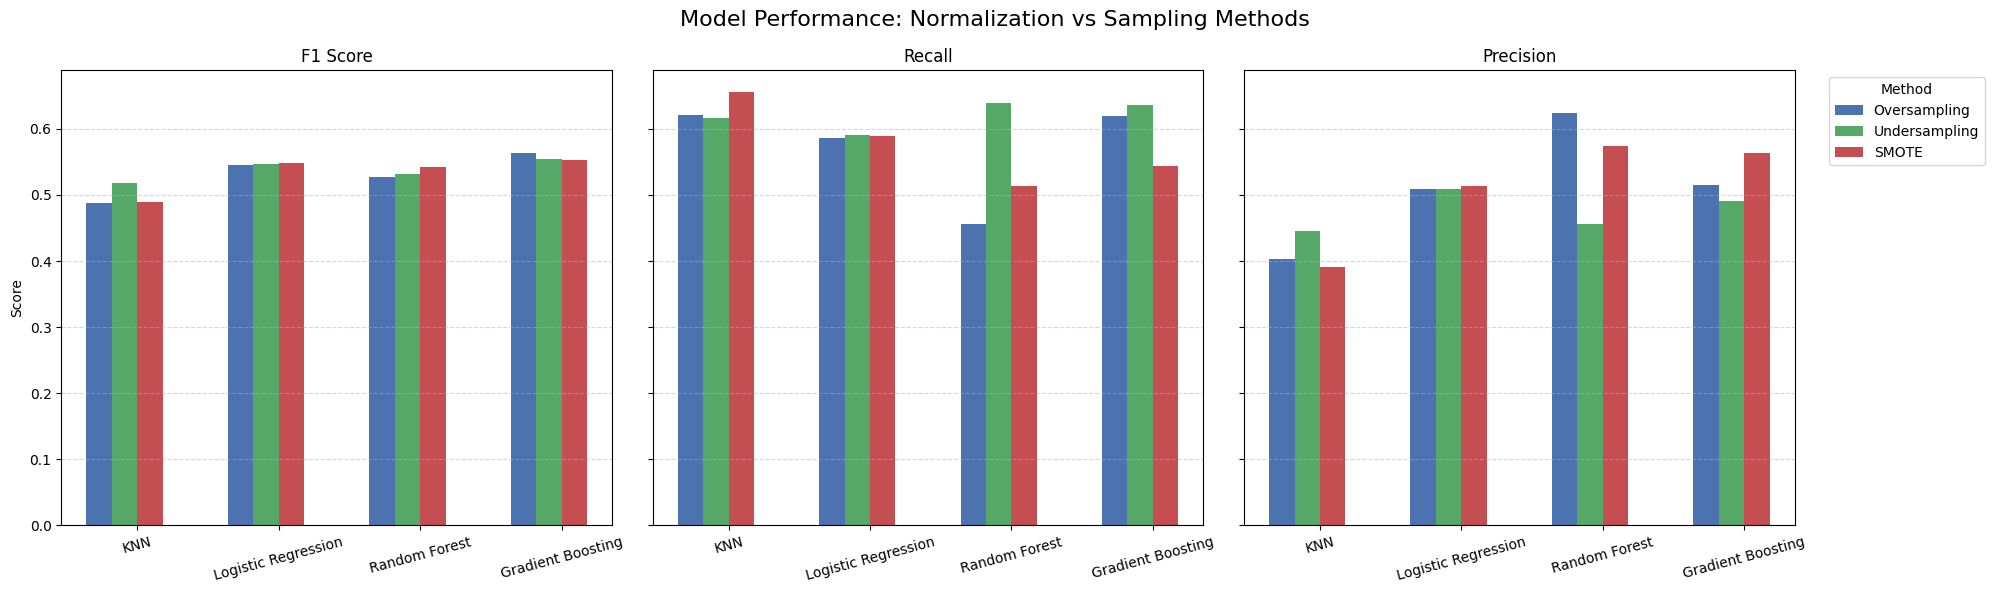

In [1082]:
# Plot setup
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
bar_width = 0.18
x = range(len(models))

# Sampling methods and colors
methods = ["Oversampling", "Undersampling", "SMOTE"]
colors = [ "#4C72B0", "#55A868", "#C44E52"]

# F1 Score subplot
for i, method in enumerate(methods):
    axes[0].bar([j + bar_width*(i-1.5) for j in x], f1_scores[method], width=bar_width, label=method, color=colors[i])
axes[0].set_title("F1 Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylabel("Score")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Recall subplot
for i, method in enumerate(methods):
    axes[1].bar([j + bar_width*(i-1.5) for j in x], recall_scores[method], width=bar_width, label=method, color=colors[i])
axes[1].set_title("Recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Precision subplot
for i, method in enumerate(methods):
    axes[2].bar([j + bar_width*(i-1.5) for j in x], precision_scores[method], width=bar_width, label=method, color=colors[i])
axes[2].set_title("Precision")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)

# Final touches
fig.suptitle("Model Performance: Normalization vs Sampling Methods", fontsize=16)
axes[2].legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

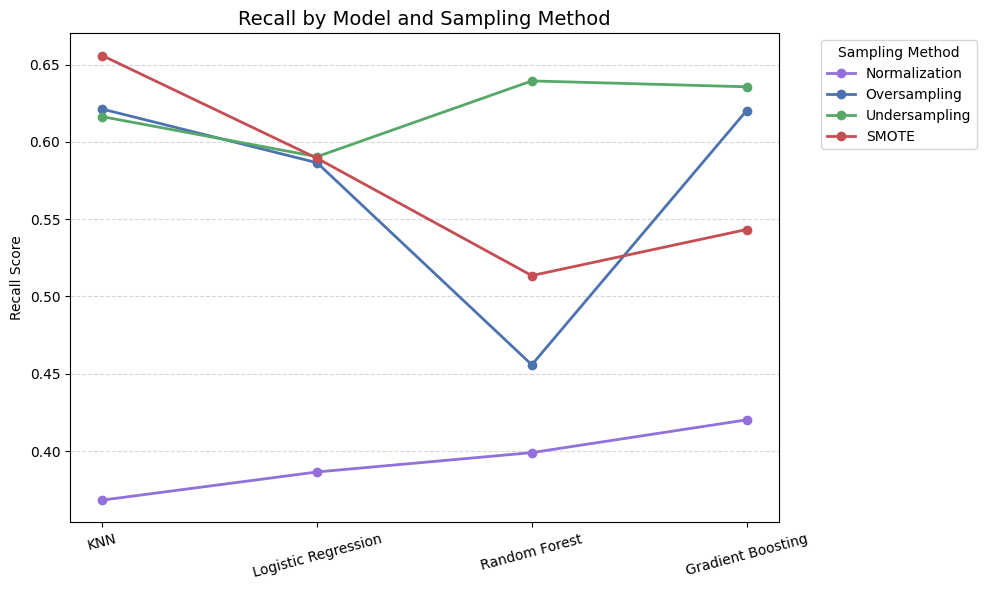

In [1070]:
import matplotlib.pyplot as plt

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(models))  # indices des modèles

# Sampling methods and colors
methods = ["Normalization", "Oversampling", "Undersampling", "SMOTE"]
colors = ["#9370DB", "#4C72B0", "#55A868", "#C44E52"]

# Line plot for Recall
for i, method in enumerate(methods):
    ax.plot(x, recall_scores[method], label=method, color=colors[i], marker='o', linewidth=2)

# Styling
ax.set_title("Recall by Model and Sampling Method", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Recall Score")
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

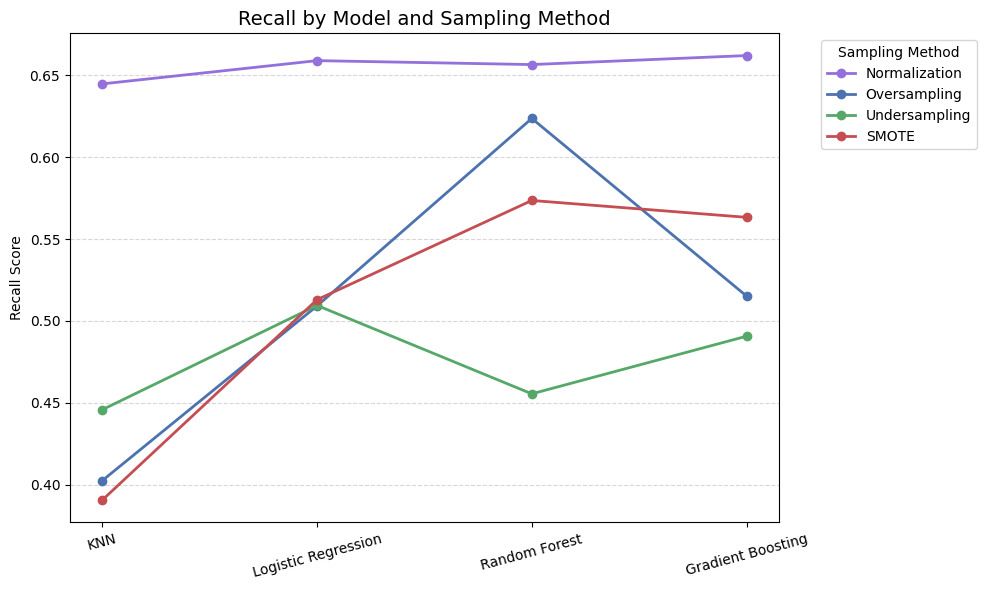

In [ ]:
import matplotlib.pyplot as plt

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(models))  # indices des modèles

# Sampling methods and colors
methods = ["Normalization", "Oversampling", "Undersampling", "SMOTE"]
colors = ["#9370DB", "#4C72B0", "#55A868", "#C44E52"]

# Line plot for Recall
for i, method in enumerate(methods):
    ax.plot(x, precision_scores[method], label=method, color=colors[i], marker='o', linewidth=2)

# Styling
ax.set_title("Recall by Model and Sampling Method", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Recall Score")
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

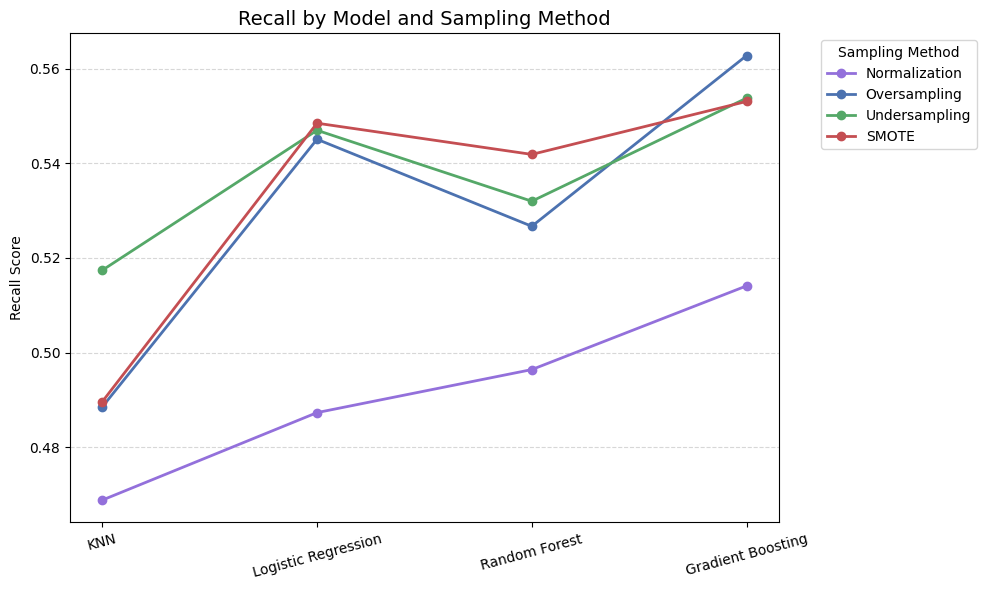

In [1072]:
import matplotlib.pyplot as plt

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(models))  # indices des modèles

# Sampling methods and colors
methods = ["Normalization", "Oversampling", "Undersampling", "SMOTE"]
colors = ["#9370DB", "#4C72B0", "#55A868", "#C44E52"]

# Line plot for Recall
for i, method in enumerate(methods):
    ax.plot(x, f1_scores[method], label=method, color=colors[i], marker='o', linewidth=2)

# Styling
ax.set_title("Recall by Model and Sampling Method", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Recall Score")
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

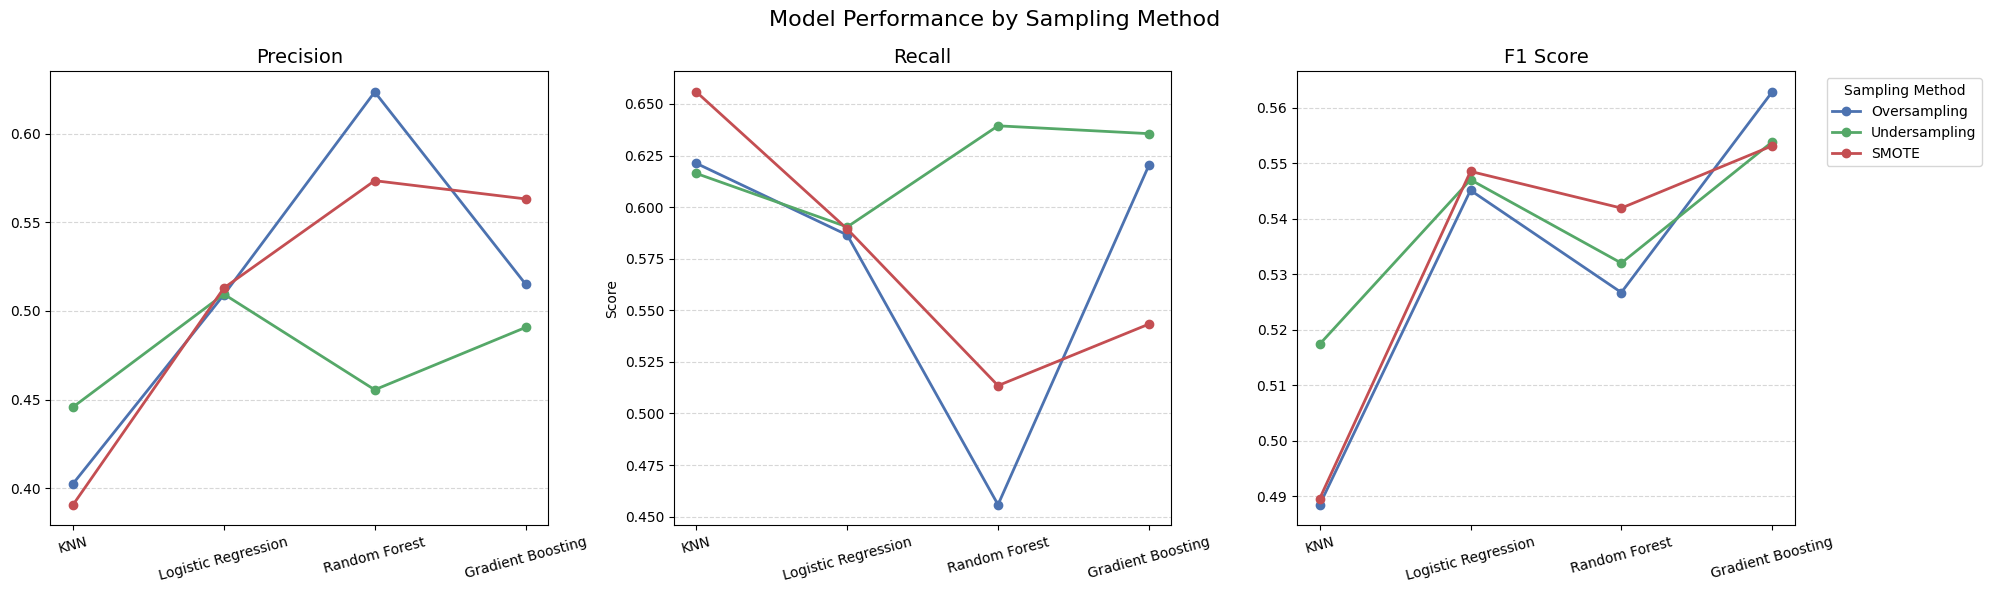

In [1080]:
# Setup
x = range(len(models))  # indices des modèles
methods = ["Oversampling", "Undersampling", "SMOTE"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# 1. Precision subplot
for i, method in enumerate(methods):
    axes[0].plot(x, precision_scores[method], label=method, color=colors[i], marker='o', linewidth=2)
axes[0].set_title("Precision", fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# 2. Recall subplot
for i, method in enumerate(methods):
    axes[1].plot(x, recall_scores[method], label=method, color=colors[i], marker='o', linewidth=2)
axes[1].set_title("Recall", fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel("Score")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# 3. F1 Score subplot
for i, method in enumerate(methods):
    axes[2].plot(x, f1_scores[method], label=method, color=colors[i], marker='o', linewidth=2)
axes[2].set_title("F1 Score", fontsize=14)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)

# Final touches
fig.suptitle("Model Performance by Sampling Method", fontsize=16)
axes[2].legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [1063]:


# Define models and sampling methods
models = ["KNN", "Logistic Regression", "Random Forest", "Gradient Boosting"]
methods = ["Normalization", "Oversampling", "Undersampling", "SMOTE"]

# AUC scores
auc_scores = {
    "Normalization": [0.7534, 0.7746, 0.7737, 0.7740],
    "Oversampling":  [0.7376, 0.7762, 0.7775, 0.7873],
    "Undersampling": [0.7607, 0.7754, 0.7793, 0.7865],
    "SMOTE":         [0.7422, 0.7746, 0.7737, 0.7740],
}

# Build long-format DataFrame
rows = []
for method in methods:
    for i, model in enumerate(models):
        rows.append({
            "Model": model,
            "Sampling": method,
            "AUC": auc_scores[method][i]
        })

auc_df = pd.DataFrame(rows)
auc_df

,Model,Sampling,AUC
0,KNN,Normalization,0.7534
1,Logistic Regression,Normalization,0.7746
2,Random Forest,Normalization,0.7737
3,Gradient Boosting,Normalization,0.7740
4,KNN,Oversampling,0.7376
5,Logistic Regression,Oversampling,0.7762
6,Random Forest,Oversampling,0.7775
7,Gradient Boosting,Oversampling,0.7873
8,KNN,Undersampling,0.7607
9,Logistic Regression,Undersampling,0.7754


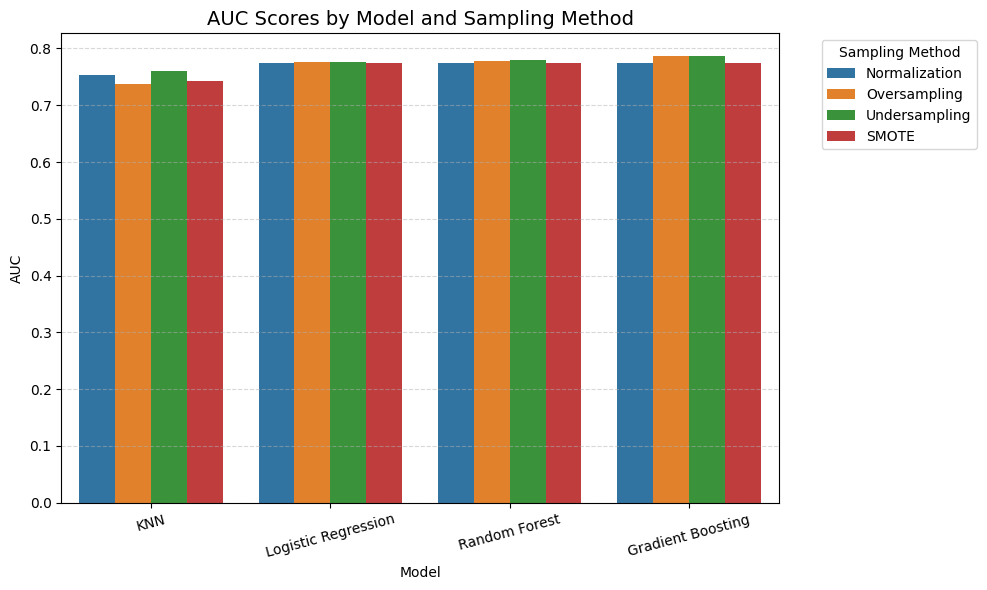

In [1064]:

# Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=auc_df, x="Model", y="AUC", hue="Sampling", palette="tab10")

# Styling
plt.title("AUC Scores by Model and Sampling Method", fontsize=14)
plt.ylabel("AUC")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

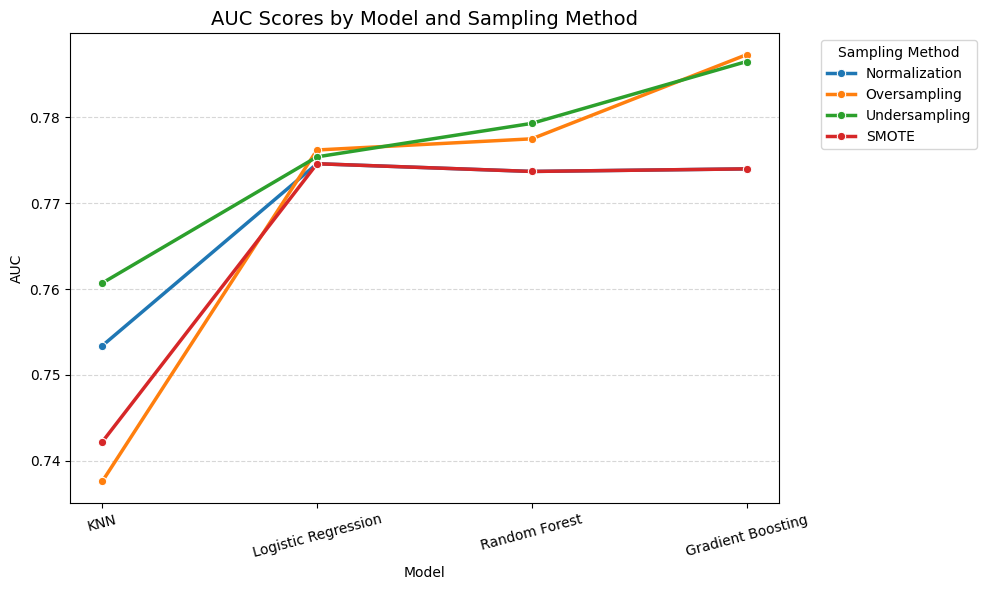

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=auc_df, x="Model", y="AUC", hue="Sampling", marker="o", linewidth=2.5)

# Style
plt.title("AUC Scores by Model and Sampling Method", fontsize=14)
plt.ylabel("AUC")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Feature Selection

In [1066]:
df_taiwan_FE.corr()

,Amount_of_Credit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sep_2005,Repayment_Status_Aug_2005,Repayment_Status_Jul_2005,Repayment_Status_Jun_2005,Repayment_Status_May_2005,...,Bill_Statement_Jun_2005,Bill_Statement_May_2005,Bill_Statement_Apr_2005,Previous_Payment_Sep_2005,Previous_Payment_Aug_2005,Previous_Payment_Jul_2005,Previous_Payment_Jun_2005,Previous_Payment_May_2005,Previous_Payment_Apr_2005,Default_Payment_Next_Month
Amount_of_Credit,1.000000,-0.019349,0.240076,0.098033,0.123500,-0.124342,-0.130240,-0.123346,-0.118709,-0.110173,...,0.406947,0.405660,0.395285,0.223196,0.223476,0.237088,0.226402,0.246167,0.240682,-0.173595
Gender,-0.019349,1.000000,0.015067,-0.033269,0.104694,0.023822,0.026835,0.026339,0.025337,0.026573,...,0.008951,0.006127,0.007041,0.001638,0.000939,0.007381,0.002598,0.006190,-0.000708,0.039121
Education_Level,0.240076,0.015067,1.000000,-0.159196,-0.206049,-0.030968,-0.025562,-0.014873,-0.014784,-0.004436,...,0.054036,0.058170,0.054537,0.058814,0.059155,0.065303,0.056125,0.062032,0.063823,-0.051687
Marital_Status,0.098033,-0.033269,-0.159196,1.000000,0.408558,0.034384,0.037269,0.022980,0.027410,0.024929,...,0.040685,0.041762,0.038452,0.006462,0.004605,0.003336,0.010558,0.004278,0.007002,0.030420
Age,0.123500,0.104694,-0.206049,0.408558,1.000000,0.016149,0.018093,0.010800,0.017652,0.009013,...,0.075462,0.072856,0.071029,0.026646,0.028978,0.032660,0.022073,0.023581,0.019536,0.010668
Repayment_Status_Sep_2005,-0.124342,0.023822,-0.030968,0.034384,0.016149,1.000000,0.787847,0.558722,0.475405,0.431499,...,-0.089393,-0.078686,-0.076625,-0.061430,-0.041624,-0.040886,-0.055316,-0.047148,-0.033062,0.424552
Repayment_Status_Aug_2005,-0.130240,0.026835,-0.025562,0.037269,0.018093,0.787847,1.000000,0.670410,0.511972,0.451361,...,-0.109086,-0.098075,-0.094617,-0.076723,-0.042225,-0.044114,-0.052602,-0.051175,-0.033856,0.341367
Repayment_Status_Jul_2005,-0.123346,0.026339,-0.014873,0.022980,0.010800,0.558722,0.670410,1.000000,0.673880,0.529081,...,-0.128220,-0.113412,-0.107900,-0.047394,-0.055200,-0.038573,-0.046792,-0.050208,-0.041493,0.295248
Repayment_Status_Jun_2005,-0.118709,0.025337,-0.014784,0.027410,0.017652,0.475405,0.511972,0.673880,1.000000,0.711313,...,-0.130185,-0.110189,-0.099354,-0.063114,-0.046081,-0.034380,-0.044736,-0.051792,-0.048679,0.277025
Repayment_Status_May_2005,-0.110173,0.026573,-0.004436,0.024929,0.009013,0.431499,0.451361,0.529081,0.711313,1.000000,...,-0.125991,-0.105287,-0.091403,-0.063952,-0.052468,-0.042818,-0.025331,-0.044519,-0.044461,0.266401


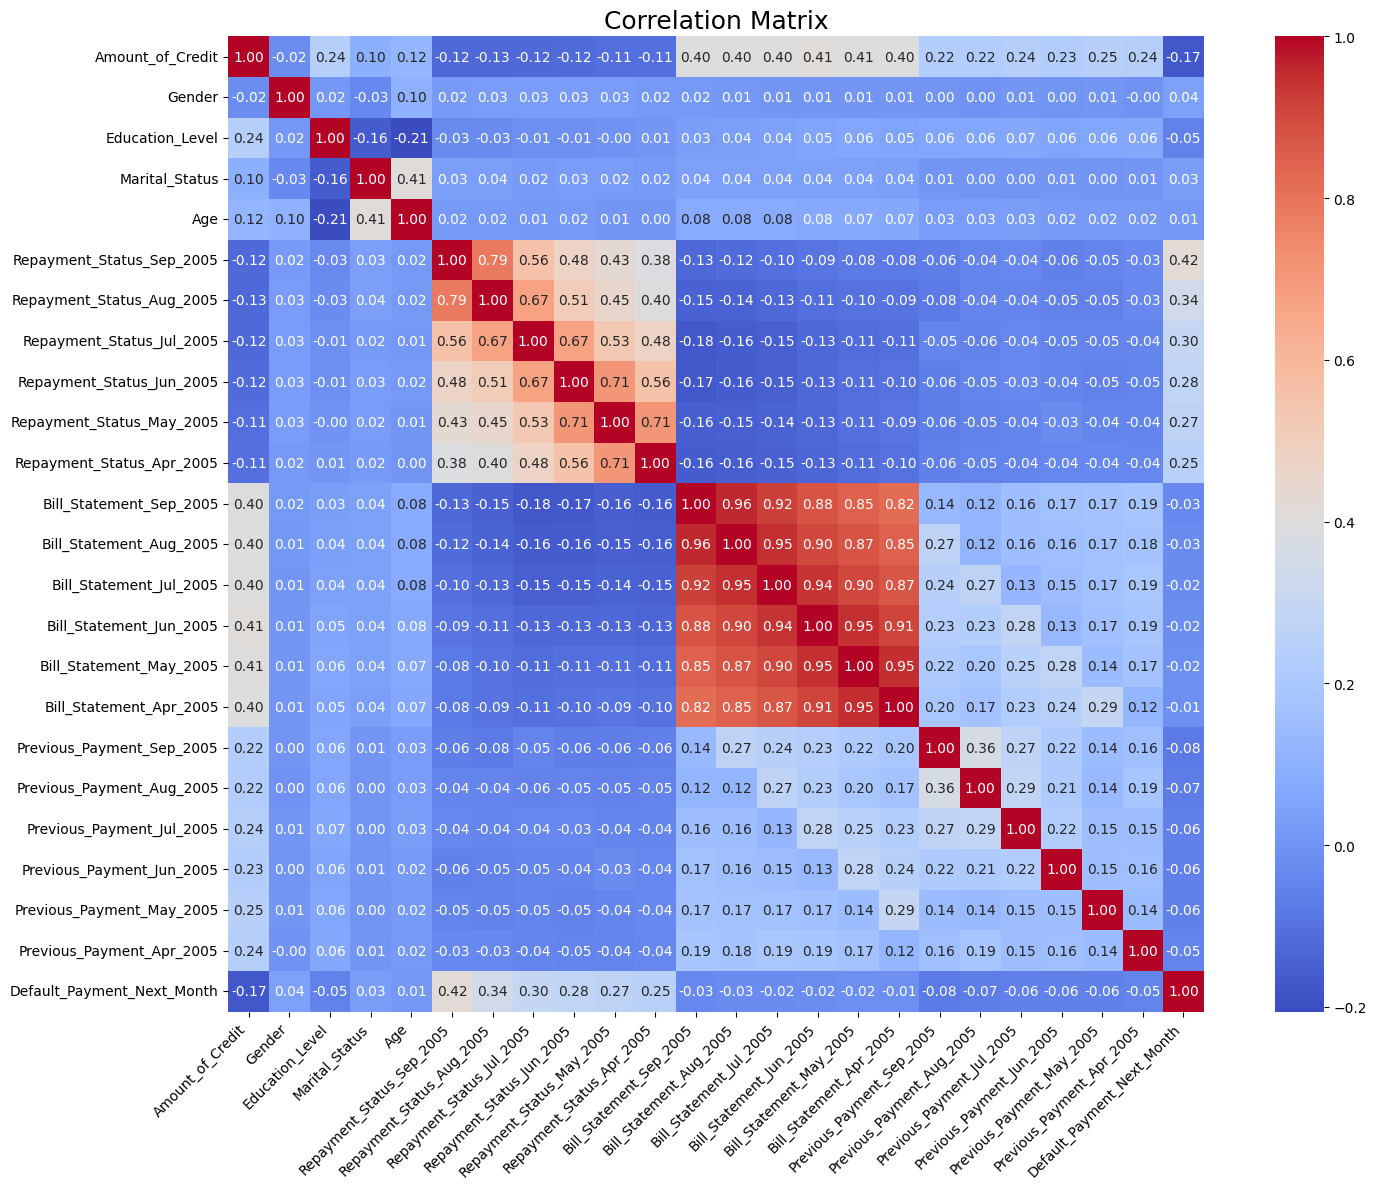

In [1067]:
plt.figure(figsize=(16, 12))  
sns.heatmap(df_taiwan_FE.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1068]:
df_taiwan_FE.columns

Index(['Amount_of_Credit', 'Gender', 'Education_Level', 'Marital_Status',
       'Age', 'Repayment_Status_Sep_2005', 'Repayment_Status_Aug_2005',
       'Repayment_Status_Jul_2005', 'Repayment_Status_Jun_2005',
       'Repayment_Status_May_2005', 'Repayment_Status_Apr_2005',
       'Bill_Statement_Sep_2005', 'Bill_Statement_Aug_2005',
       'Bill_Statement_Jul_2005', 'Bill_Statement_Jun_2005',
       'Bill_Statement_May_2005', 'Bill_Statement_Apr_2005',
       'Previous_Payment_Sep_2005', 'Previous_Payment_Aug_2005',
       'Previous_Payment_Jul_2005', 'Previous_Payment_Jun_2005',
       'Previous_Payment_May_2005', 'Previous_Payment_Apr_2005',
       'Default_Payment_Next_Month'],
      dtype='object')

In [1069]:


for col in df_taiwan_FE.columns:
    if col=='Default_Payment_Next_Month':
        continue
    fig=px.histogram(df_taiwan_FE,x=col,color='Default_Payment_Next_Month')
    fig.show()